# Factory Insight AI - Model Comparison

## 1. 目的

ベースラインとして構築したLogisticRegressionでは、
判定閾値を調整することで故障の見逃しを減らすことができた。

一方、False Positiveが多く、Precisionが低いという課題が残った。

EDAでは、単一特徴量との線形関係だけでなく、
複数特徴量の組み合わせや非線形な関係が
設備故障に関係している可能性が確認された。

そこで本NotebookではRandomForestを構築し、
非線形モデルによって予測性能を改善できるか検証する。

さらに、EDAで作成した派生特徴量を追加し、
特徴量エンジニアリングによる性能改善効果も検証する。

## 2. データ読み込み

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(10000, 14)

## 3. 特徴量と目的変数

In [2]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

categorical_features = [
    "Type",
]

target = "Machine failure"

X = df[numeric_features + categorical_features]
y = df[target]

X.shape, y.shape

((10000, 6), (10000,))

## 4. Train / Validation / Test分割

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

In [4]:
print("Sub-train:", X_subtrain.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

print()
print("Sub-train failure rate:", y_subtrain.mean())
print("Validation failure rate:", y_valid.mean())
print("Test failure rate:", y_test.mean())

Sub-train: (6400, 6)
Validation: (1600, 6)
Test: (2000, 6)

Sub-train failure rate: 0.03390625
Validation failure rate: 0.03375
Test failure rate: 0.034


## 5. 評価関数

In [5]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(
            y_true,
            y_proba,
        ),
    }

## 6. RandomForest

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            categorical_features,
        ),
    ]
)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [8]:
rf_model.fit(
    X_subtrain,
    y_subtrain,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [9]:
rf_valid_proba = rf_model.predict_proba(
    X_valid
)[:, 1]

In [10]:
rf_valid_pred_05 = (
    rf_valid_proba >= 0.5
).astype(int)

rf_valid_metrics_05 = evaluate_model(
    y_valid,
    rf_valid_pred_05,
    rf_valid_proba,
)

pd.Series(rf_valid_metrics_05)

Accuracy             0.983125
Precision            0.935484
Recall               0.537037
F1                   0.682353
ROC-AUC              0.966760
Average Precision    0.785160
dtype: float64

In [11]:
confusion_matrix(
    y_valid,
    rf_valid_pred_05,
)

array([[1544,    2],
       [  25,   29]])

## 7. 閾値最適化

In [12]:
thresholds = np.linspace(
    0.01,
    0.50,
    100,
)

rf_threshold_results = []

for threshold in thresholds:
    pred = (
        rf_valid_proba >= threshold
    ).astype(int)

    rf_threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_valid,
                pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_valid,
                pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_valid,
                pred,
                zero_division=0,
            ),
        }
    )

rf_threshold_results = pd.DataFrame(
    rf_threshold_results
)

rf_threshold_results.head()

,threshold,precision,recall,f1
0,0.010000,0.132170,0.981481,0.232967
1,0.014949,0.162500,0.962963,0.278075
2,0.019899,0.172881,0.944444,0.292264
3,0.024848,0.194553,0.925926,0.321543
4,0.029798,0.206612,0.925926,0.337838


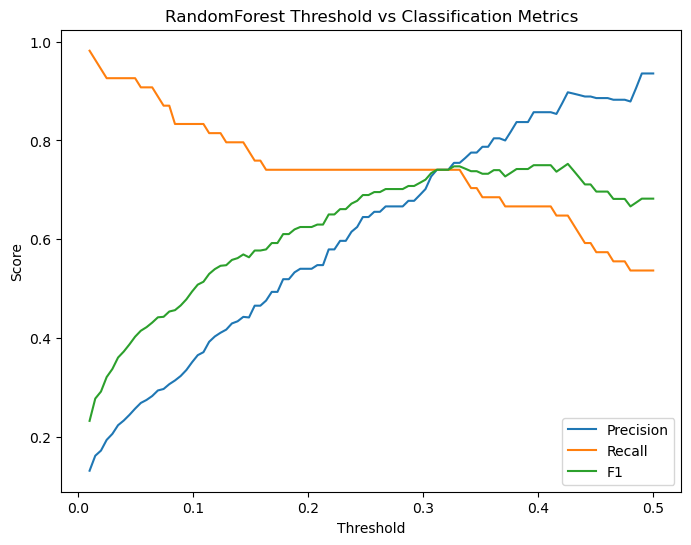

In [13]:
plt.figure(figsize=(8, 6))

plt.plot(
    rf_threshold_results["threshold"],
    rf_threshold_results["precision"],
    label="Precision",
)

plt.plot(
    rf_threshold_results["threshold"],
    rf_threshold_results["recall"],
    label="Recall",
)

plt.plot(
    rf_threshold_results["threshold"],
    rf_threshold_results["f1"],
    label="F1",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("RandomForest Threshold vs Classification Metrics")
plt.legend()
plt.show()

In [14]:
rf_threshold_candidates = rf_threshold_results[
    rf_threshold_results["recall"] >= 0.80
].copy()

rf_threshold_candidates.sort_values(
    ["precision", "threshold"],
    ascending=[False, False],
).head(10)

,threshold,precision,recall,f1
23,0.123838,0.411215,0.814815,0.546584
22,0.118889,0.403670,0.814815,0.539877
21,0.113939,0.392857,0.814815,0.530120
20,0.108990,0.371901,0.833333,0.514286
19,0.104040,0.365854,0.833333,0.508475
18,0.099091,0.351562,0.833333,0.494505
17,0.094141,0.335821,0.833333,0.478723
16,0.089192,0.323741,0.833333,0.466321
15,0.084242,0.314685,0.833333,0.456853
14,0.079293,0.307190,0.870370,0.454106


In [15]:
rf_best_f1_row = rf_threshold_results.loc[
    rf_threshold_results["f1"].idxmax()
]

rf_best_f1_row

threshold    0.425758
precision    0.897436
recall       0.648148
f1           0.752688
Name: 84, dtype: float64

In [16]:
rf_best_recall80_row = (
    rf_threshold_candidates
    .sort_values(
        ["precision", "threshold"],
        ascending=[False, False],
    )
    .iloc[0]
)

rf_best_recall80_row

threshold    0.123838
precision    0.411215
recall       0.814815
f1           0.546584
Name: 23, dtype: float64

### RandomForestの閾値選択

RandomForestをデフォルト閾値0.5で評価した結果、
ValidationデータではPrecision 0.935、Recall 0.537、
F1 0.682、ROC-AUC 0.967、Average Precision 0.785となった。

故障と判定した設備のPrecisionは高い一方、
故障の約46%を見逃している。

そこで、ベースラインモデルと同様に
「Recall 0.80以上を満たす中でPrecisionを最大化する」
という基準でValidationデータから判定閾値を探索した。

その結果、閾値約0.124で
Precision 0.411、Recall 0.815、F1 0.547となった。

ベースラインのLogisticRegressionでは、
同程度のRecallを確保した場合のPrecisionが約0.13だったため、
RandomForestでは故障の検出率を維持しながら
False Positiveを減らせる可能性が示された。

また、F1が最大となった閾値は約0.426で、
Precision 0.897、Recall 0.648、F1 0.753だった。

本プロジェクトでは故障の見逃しを重視するため、
最終評価にはRecall 0.80以上という条件から選択した
約0.124の閾値を使用する。

In [18]:
selected_rf_threshold = rf_best_recall80_row["threshold"]

selected_rf_threshold

np.float64(0.12383838383838383)

In [19]:
rf_final_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_final_model.fit(
    X_train,
    y_train,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [20]:
rf_test_proba = rf_final_model.predict_proba(
    X_test
)[:, 1]

rf_test_pred = (
    rf_test_proba >= selected_rf_threshold
).astype(int)

In [21]:
rf_test_metrics = evaluate_model(
    y_test,
    rf_test_pred,
    rf_test_proba,
)

pd.Series(rf_test_metrics)

Accuracy             0.955500
Precision            0.425532
Recall               0.882353
F1                   0.574163
ROC-AUC              0.970866
Average Precision    0.790335
dtype: float64

In [22]:
rf_test_cm = confusion_matrix(
    y_test,
    rf_test_pred,
)

rf_test_cm

array([[1851,   81],
       [   8,   60]])

## 8. LogisticRegressionとの比較

In [23]:
logistic_test_metrics = {
    "Accuracy": 0.8135,
    "Precision": 0.129,
    "Recall": 0.779,
    "F1": 0.221,
    "ROC-AUC": 0.899,
    "Average Precision": 0.421,
}

model_comparison = pd.DataFrame(
    {
        "LogisticRegression": logistic_test_metrics,
        "RandomForest": rf_test_metrics,
    }
).T

model_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
LogisticRegression,0.8135,0.129000,0.779000,0.221000,0.899000,0.421000
RandomForest,0.9555,0.425532,0.882353,0.574163,0.970866,0.790335


## 8. LogisticRegressionとの比較

Validationデータで決定した判定閾値を固定し、
Trainデータ全体でRandomForestを再学習した後、
Testデータで最終評価を行った。

RandomForestではPrecision 0.426、Recall 0.882、
F1 0.574、ROC-AUC 0.971、Average Precision 0.790となった。

故障68件のうち60件を正しく検出し、
見逃しは8件だった。
また、正常設備1,932件のうち誤って故障と判定した設備は81件だった。

ベースラインのLogisticRegressionでは、
Precision 0.129、Recall 0.779、F1 0.221であり、
故障15件を見逃し、正常設備358件を故障と誤判定していた。

RandomForestではRecallが0.779から0.882へ向上すると同時に、
Precisionも0.129から0.426へ大きく向上した。

また、ROC-AUCは0.899から0.971、
Average Precisionは0.421から0.790へ向上している。

この結果から、単純な線形モデルよりも、
特徴量間の相互作用や非線形な関係を扱えるRandomForestの方が、
本データの故障予測に適している可能性が示された。

## 9. 派生特徴量

In [24]:
df_featured = df.copy()

In [25]:
df_featured["Power [W]"] = (
    2
    * np.pi
    * df_featured["Rotational speed [rpm]"]
    * df_featured["Torque [Nm]"]
    / 60
)

df_featured["Wear-Torque"] = (
    df_featured["Tool wear [min]"]
    * df_featured["Torque [Nm]"]
)

df_featured["Temperature difference [K]"] = (
    df_featured["Process temperature [K]"]
    - df_featured["Air temperature [K]"]
)

In [26]:
df_featured[
    [
        "Power [W]",
        "Wear-Torque",
        "Temperature difference [K]",
    ]
].describe()

,Power [W],Wear-Torque,Temperature difference [K]
count,10000.000000,10000.000000,10000.000000
mean,6279.744953,4314.664550,10.000630
std,1067.418295,2826.567692,1.001094
min,1148.440610,0.000000,7.600000
25%,5561.184484,1963.650000,9.300000
50%,6271.027344,4012.950000,9.800000
75%,7003.002724,6279.000000,11.000000
max,10469.923005,16497.000000,12.100000


In [27]:
derived_features = [
    "Power [W]",
    "Wear-Torque",
    "Temperature difference [K]",
]

featured_numeric_features = (
    numeric_features + derived_features
)

X_featured = df_featured[
    featured_numeric_features
    + categorical_features
]

y_featured = df_featured[target]

X_featured.shape

(10000, 9)

In [28]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_featured,
    y_featured,
    test_size=0.2,
    random_state=42,
    stratify=y_featured,
)

Xf_subtrain, Xf_valid, yf_subtrain, yf_valid = train_test_split(
    Xf_train,
    yf_train,
    test_size=0.2,
    random_state=42,
    stratify=yf_train,
)

In [29]:
print(
    np.array_equal(
        y_train.to_numpy(),
        yf_train.to_numpy(),
    )
)

print(
    np.array_equal(
        y_test.to_numpy(),
        yf_test.to_numpy(),
    )
)

True
True


## 10. 派生特徴量ありRandomForest

In [30]:
featured_rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            featured_numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            categorical_features,
        ),
    ]
)

In [31]:
featured_rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            featured_rf_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

featured_rf_model.fit(
    Xf_subtrain,
    yf_subtrain,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Power [W]', 'Wear-Torque',
                                                   'Temperature difference '
                                                   '[K]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [32]:
featured_rf_valid_proba = (
    featured_rf_model.predict_proba(
        Xf_valid
    )[:, 1]
)

In [33]:
featured_rf_valid_pred_05 = (
    featured_rf_valid_proba >= 0.5
).astype(int)

featured_rf_valid_metrics_05 = evaluate_model(
    yf_valid,
    featured_rf_valid_pred_05,
    featured_rf_valid_proba,
)

pd.Series(featured_rf_valid_metrics_05)

Accuracy             0.992500
Precision            1.000000
Recall               0.777778
F1                   0.875000
ROC-AUC              0.967365
Average Precision    0.874875
dtype: float64

In [34]:
featured_threshold_results = []

for threshold in thresholds:
    pred = (
        featured_rf_valid_proba >= threshold
    ).astype(int)

    featured_threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                yf_valid,
                pred,
                zero_division=0,
            ),
            "recall": recall_score(
                yf_valid,
                pred,
                zero_division=0,
            ),
            "f1": f1_score(
                yf_valid,
                pred,
                zero_division=0,
            ),
        }
    )

featured_threshold_results = pd.DataFrame(
    featured_threshold_results
)

In [35]:
featured_threshold_candidates = (
    featured_threshold_results[
        featured_threshold_results["recall"] >= 0.80
    ].copy()
)

featured_best_recall80_row = (
    featured_threshold_candidates
    .sort_values(
        ["precision", "threshold"],
        ascending=[False, False],
    )
    .iloc[0]
)

featured_best_recall80_row

threshold    0.257475
precision    0.862745
recall       0.814815
f1           0.838095
Name: 50, dtype: float64

In [36]:
featured_best_f1_row = (
    featured_threshold_results.loc[
        featured_threshold_results["f1"].idxmax()
    ]
)

featured_best_f1_row

threshold    0.401010
precision    1.000000
recall       0.777778
f1           0.875000
Name: 79, dtype: float64

### 派生特徴量のValidation評価

Power、Wear-Torque、Temperature differenceの3つの派生特徴量を追加し、
元特徴量のみの場合と同じRandomForestで性能を評価した。

Recall 0.80以上という条件で判定閾値を選択した結果、
閾値約0.257でPrecision 0.863、Recall 0.815、
F1 0.838となった。

元特徴量のみのRandomForestでは、
同じRecall 0.815に対してPrecisionは0.411、F1は0.547だった。

したがって、Validationデータでは故障の検出率を維持したまま、
派生特徴量の追加によってFalse Positiveを大幅に減らせる可能性が示された。

また、Average Precisionも向上しており、
派生特徴量によって故障設備の順位付け性能も改善している。

一方、この結果はValidationデータで得られたものであるため、
派生特徴量の有効性を最終的に判断するには、
Validationで決定した閾値を固定したうえでTestデータを評価する必要がある。

In [37]:
selected_featured_rf_threshold = (
    featured_best_recall80_row["threshold"]
)

selected_featured_rf_threshold

np.float64(0.25747474747474747)

In [38]:
featured_rf_final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            featured_rf_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

featured_rf_final_model.fit(
    Xf_train,
    yf_train,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Power [W]', 'Wear-Torque',
                                                   'Temperature difference '
                                                   '[K]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [39]:
featured_rf_test_proba = (
    featured_rf_final_model.predict_proba(
        Xf_test
    )[:, 1]
)

featured_rf_test_pred = (
    featured_rf_test_proba
    >= selected_featured_rf_threshold
).astype(int)

In [40]:
featured_rf_test_metrics = evaluate_model(
    yf_test,
    featured_rf_test_pred,
    featured_rf_test_proba,
)

pd.Series(featured_rf_test_metrics)

Accuracy             0.990000
Precision            0.863636
Recall               0.838235
F1                   0.850746
ROC-AUC              0.979601
Average Precision    0.893332
dtype: float64

In [42]:
featured_rf_test_cm = confusion_matrix(
    yf_test,
    featured_rf_test_pred,
)

featured_rf_test_cm

array([[1923,    9],
       [  11,   57]])

In [44]:
final_model_comparison = pd.DataFrame(
    {
        "LogisticRegression": logistic_test_metrics,
        "RandomForest": rf_test_metrics,
        "RandomForest + Derived Features": (
            featured_rf_test_metrics
        ),
    }
).T

final_model_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
LogisticRegression,0.8135,0.129000,0.779000,0.221000,0.899000,0.421000
RandomForest,0.9555,0.425532,0.882353,0.574163,0.970866,0.790335
RandomForest + Derived Features,0.9900,0.863636,0.838235,0.850746,0.979601,0.893332


## 11. 特徴量重要度

In [45]:
feature_names = (
    featured_rf_final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names

array(['num__Air temperature [K]', 'num__Process temperature [K]',
       'num__Rotational speed [rpm]', 'num__Torque [Nm]',
       'num__Tool wear [min]', 'num__Power [W]', 'num__Wear-Torque',
       'num__Temperature difference [K]', 'cat__Type_H', 'cat__Type_L',
       'cat__Type_M'], dtype=object)

In [46]:
feature_importances = (
    featured_rf_final_model
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importances,
    }
).sort_values(
    "importance",
    ascending=False,
)

importance_df

,feature,importance
6,num__Wear-Torque,0.213677
5,num__Power [W],0.207252
2,num__Rotational speed [rpm],0.160045
3,num__Torque [Nm],0.133689
7,num__Temperature difference [K],0.119361
4,num__Tool wear [min],0.056620
0,num__Air temperature [K],0.038244
1,num__Process temperature [K],0.034990
9,cat__Type_L,0.018544
10,cat__Type_M,0.011959


In [47]:
importance_df["feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance_df

,feature,importance
6,Wear-Torque,0.213677
5,Power [W],0.207252
2,Rotational speed [rpm],0.160045
3,Torque [Nm],0.133689
7,Temperature difference [K],0.119361
4,Tool wear [min],0.056620
0,Air temperature [K],0.038244
1,Process temperature [K],0.034990
9,Type_L,0.018544
10,Type_M,0.011959


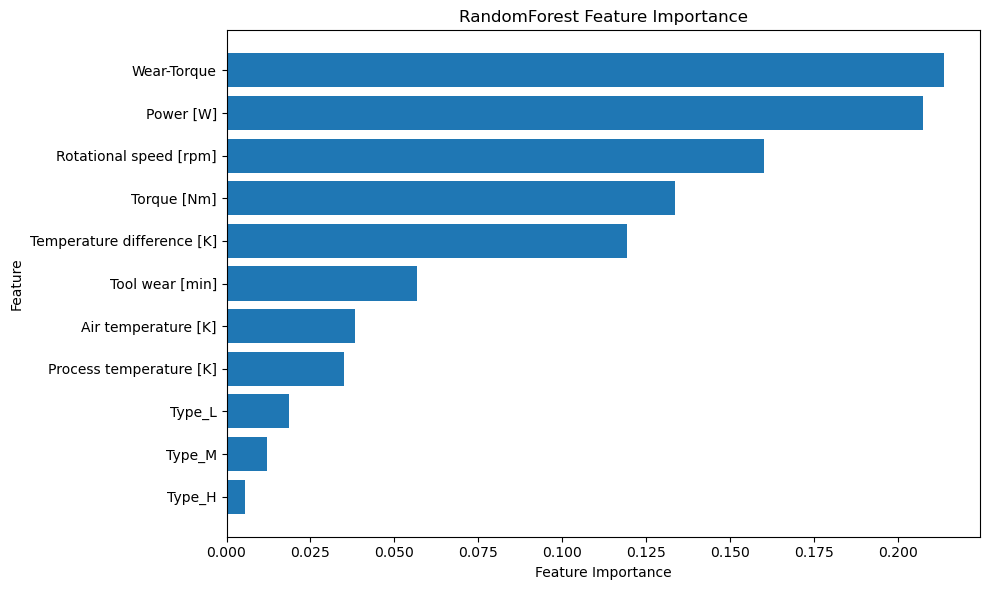

In [48]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("RandomForest Feature Importance")
plt.tight_layout()
plt.show()

## 12. モデル比較

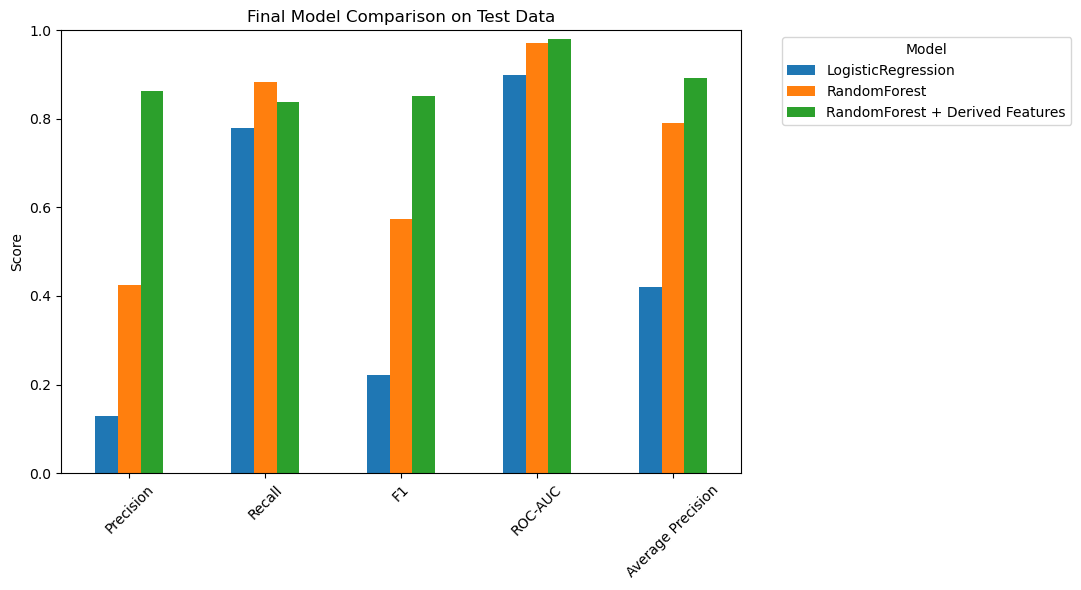

In [49]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision",
]

comparison_plot = final_model_comparison[
    metrics_to_plot
].T

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Final Model Comparison on Test Data")
plt.xticks(rotation=45)
plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

Testデータを用いて、LogisticRegression、
元特徴量のRandomForest、
派生特徴量を追加したRandomForestを比較した。

LogisticRegressionではPrecision 0.129、Recall 0.779、
F1 0.221だった。

RandomForestではPrecision 0.426、Recall 0.882、
F1 0.574となり、線形モデルと比較して大きく性能が向上した。

さらにPower、Wear-Torque、Temperature differenceを追加した
RandomForestでは、Precision 0.864、Recall 0.838、
F1 0.851となった。

Recallは元特徴量のRandomForestの0.882から0.838へ低下したものの、
事前に設定したRecall 0.80以上という目標を維持している。

一方、False Positiveは81件から9件まで減少し、
Precisionは0.426から0.864へ大きく向上した。

また、ROC-AUCは0.971から0.980、
Average Precisionは0.790から0.893へ向上した。

この結果から、派生特徴量を追加することで、
故障設備の検出率を高く維持しながら、
不要な点検につながる誤警報を大幅に削減できる可能性が示された。

## 13. 考察

### 非線形モデルの効果

ベースラインのLogisticRegressionと比較して、
RandomForestではPrecision、Recall、F1、
ROC-AUC、Average Precisionのすべてが改善した。

LogisticRegressionではPrecision 0.129、Recall 0.779だったのに対し、
RandomForestではPrecision 0.426、Recall 0.882となった。

この結果から、本データの設備故障には単一特徴量との線形な関係だけではなく、
特徴量間の相互作用や非線形な関係が含まれている可能性がある。

### 派生特徴量の効果

RandomForestにPower、Wear-Torque、
Temperature differenceを追加した結果、
Precisionは0.426から0.864、
F1は0.574から0.851へ大きく向上した。

Recallは0.882から0.838へ低下したものの、
事前に設定したRecall 0.80以上という目標は維持できた。

また、False Positiveは81件から9件まで減少した。

予知保全では、故障の見逃しを減らすことが重要である一方、
False Positiveが多すぎると正常な設備に対する不要な点検が増え、
保全担当者の作業負荷につながる。

派生特徴量を追加したモデルでは、
故障の検出率を高く維持しながら誤警報を大幅に減らせたため、
保全対象設備の優先順位付けに利用しやすいモデルになったと考えられる。

### 特徴量重要度

RandomForestの特徴量重要度では、
Wear-Torqueが最も高く、Powerが2番目、
Temperature differenceが5番目となった。

Wear-Torqueは工具摩耗とトルクを組み合わせた特徴量であり、
工具の摩耗状態と設備にかかる負荷を同時に表現している。

Powerも回転速度とトルクを組み合わせた特徴量であり、
設備の運転状態を単一のセンサー値とは異なる観点から表現している。

このように、元のセンサー値だけではなく、
設備状態を表す特徴量同士の組み合わせを作成することが、
故障予測に有効である可能性が示された。

ただし、RandomForestの特徴量重要度は因果関係を示すものではなく、
相関した特徴量が存在する場合には重要度の解釈にも注意が必要である。

そのため、今後はSHAPなどを用いて、
モデルが個々の予測をどのような根拠で行っているかについても検証する。

## 14. 次のステップ

RandomForestと派生特徴量を組み合わせることで、
ベースラインのLogisticRegressionから
故障予測性能を大きく改善できた。

一方、現在のRandomForestでは
ハイパーパラメータをほぼ初期設定のまま使用しており、
他の勾配ブースティングモデルとの比較も行っていない。

次のフェーズでは以下を検証する。

1. LightGBMを導入し、RandomForestと性能を比較する。
2. StratifiedKFoldを用いた交差検証でモデル性能の安定性を確認する。
3. クラス不均衡を考慮した学習方法を検証する。
4. Validationまたは交差検証によって判定閾値を決定する。
5. 最終候補モデルを選択する。
6. SHAPを用いて故障予測の根拠を可視化する。

最終的には、予測性能だけではなく、
故障の見逃しと誤警報のバランス、
モデルの安定性、予測根拠の説明可能性を考慮して
採用モデルを決定する。